# Lecture 3 — Class Exercise
## Line Charts & Slopegraphs: CO2 Emissions

> **Push to:** `week03/lecture03_exercise.ipynb` in your GitHub repo

### Remember:
1. No spaghetti — multiple lines must use grey + single highlight
2. Remove clutter: no chart borders, no heavy gridlines, no legend if you can label directly
3. Insight title — states the finding, not the topic
4. Carry forward from Lecture 2: white background, Arial font, professional quality


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv('../data/co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [2]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


---
## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


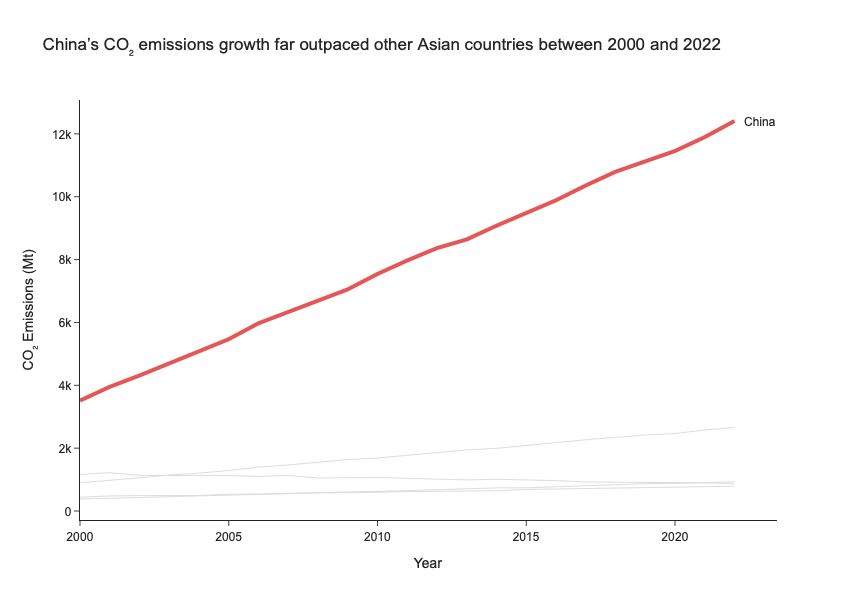

In [3]:
# Task 1 — Multi-series line with highlight
# YOUR CODE HERE
import pandas as pd
import plotly.graph_objects as go

# Filter Asia
asia = df[df['Region'] == 'Asia']

highlight_country = 'China'

fig = go.Figure()

# Background lines
for country in asia['Country'].unique():

    country_df = asia[asia['Country'] == country].sort_values('Year')

    if country != highlight_country:
        fig.add_trace(
            go.Scatter(
                x=country_df['Year'],
                y=country_df['CO2_Mt'],
                mode='lines',
                line=dict(color='#DDDDDD', width=1),
                hoverinfo='skip',
                showlegend=False
            )
        )

# Highlight line
china = asia[asia['Country'] == highlight_country].sort_values('Year')

fig.add_trace(
    go.Scatter(
        x=china['Year'],
        y=china['CO2_Mt'],
        mode='lines',
        line=dict(color='#E45756', width=4),
        showlegend=False
    )
)

# Direct label at end
fig.add_annotation(
    x=china['Year'].iloc[-1],
    y=china['CO2_Mt'].iloc[-1],
    text='China',
    showarrow=False,
    xshift=25,
    font=dict(size=12)
)

fig.update_layout(
    title='China’s CO₂ emissions growth far outpaced other Asian countries between 2000 and 2022',
    template='simple_white',
    font=dict(family='Arial'),
    xaxis_title='Year',
    yaxis_title='CO₂ Emissions (Mt)',
    height=600
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(gridcolor='#EEEEEE')

fig.show()

---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022


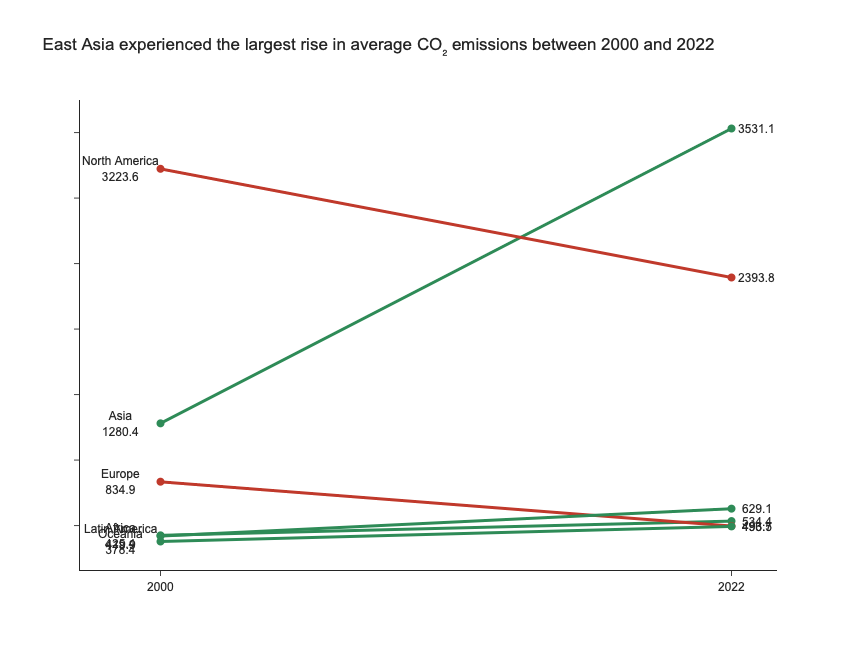

In [4]:
# Task 2 — Slopegraph: regional averages
# YOUR CODE HERE
import pandas as pd
import plotly.graph_objects as go

# Regional averages
regional = (
    df.groupby(['Region', 'Year'])['CO2_Mt']
      .mean()
      .reset_index()
)

slope = regional[regional['Year'].isin([2000, 2022])]

fig = go.Figure()

for region in slope['Region'].unique():

    region_data = slope[slope['Region'] == region]

    start = region_data[region_data['Year'] == 2000]['CO2_Mt'].values[0]
    end = region_data[region_data['Year'] == 2022]['CO2_Mt'].values[0]

    color = '#2E8B57' if end > start else '#C0392B'

    fig.add_trace(
        go.Scatter(
            x=[2000, 2022],
            y=[start, end],
            mode='lines+markers',
            line=dict(color=color, width=3),
            marker=dict(size=8),
            showlegend=False
        )
    )

    # Left label
    fig.add_annotation(
        x=2000,
        y=start,
        text=f'{region}<br>{start:.1f}',
        showarrow=False,
        xshift=-40
    )

    # Right label
    fig.add_annotation(
        x=2022,
        y=end,
        text=f'{end:.1f}',
        showarrow=False,
        xshift=25
    )

fig.update_layout(
    title='East Asia experienced the largest rise in average CO₂ emissions between 2000 and 2022',
    template='simple_white',
    font=dict(family='Arial'),
    xaxis=dict(
        tickvals=[2000, 2022]
    ),
    yaxis=dict(
        showticklabels=False,
        title=''
    ),
    height=650
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()